# Stress Testing & Scenario Analysis Engine for Equity & ETF Portfolios

Author: Enrique Sabariego 

Target Roles: Market Risk Analyst / Quantitative Analyst  

Context: Banking & Asset Management Risk Practices  

This notebook presents the design and implementation of a stress testing and scenario analysis engine applied to a diversified equity and ETF portfolio, inspired by market risk frameworks used in banking and insurance institutions.


## 1. Motivation and Risk Management Context

Traditional market risk metrics such as Value-at-Risk (VaR) and Expected Shortfall (ES) rely on historical distributions and may fail to fully capture extreme but plausible market events.

Stress testing and scenario analysis are therefore essential tools used by:
- Market Risk teams
- Risk Committees
- Regulatory frameworks (Basel, ICAAP, internal risk appetite)

This project aims to evaluate portfolio resilience under severe market conditions using both historical and hypothetical stress scenarios.


## 2. Methodological Overview

The stress testing framework is structured as follows:
1. Portfolio construction (equities & ETFs)
2. Baseline market risk assessment (VaR, ES, drawdowns)
3. Historical stress scenarios (2008 Financial Crisis, COVID-19)
4. Hypothetical shocks (volatility and correlation stress)
5. Sensitivity analysis to key market risk factors


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
np.random.seed(42)


## 3. Portfolio Construction

We consider a simplified but realistic long-only portfolio composed of:
- US equities
- European equities
- Emerging markets
- Sector and broad market ETFs

Weights are assumed to be fixed to isolate pure market risk effects.


In [36]:
import yfinance as yf

# -------------------------------------------------------
# Portfolio definition
# -------------------------------------------------------
# SPY  : US Equity (S&P 500)
# EFA  : Developed Markets ex-US
# EEM  : Emerging Markets
# QQQ  : US Tech / Growth
tickers = ["SPY", "EFA", "EEM", "QQQ"]

start_date = "2005-01-01"
end_date = "2023-12-31"

# -------------------------------------------------------
# Download adjusted close prices
# -------------------------------------------------------
prices = (
    yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )["Adj Close"]
)

# Drop dates with missing values
prices = prices.dropna()

# -------------------------------------------------------
# Compute log-returns
# -------------------------------------------------------
returns = np.log(prices / prices.shift(1)).dropna()

# -------------------------------------------------------
# Portfolio weights (fixed, long-only)
# -------------------------------------------------------
weights = np.array([0.35, 0.25, 0.20, 0.20])

# Sanity check
assert np.isclose(weights.sum(), 1.0), "Portfolio weights must sum to 1"

# -------------------------------------------------------
# Portfolio returns
# -------------------------------------------------------
portfolio_returns = returns @ weights

portfolio_returns.name = "Portfolio Returns"


## 4. Baseline Market Risk Metrics

Before applying stress scenarios, we compute baseline market risk indicators:
- Historical Value-at-Risk (VaR)
- Expected Shortfall (ES)
- Maximum drawdown

These metrics serve as a benchmark for stressed outcomes.




In [37]:
def compute_var_es(returns, alpha=0.95):
    var = np.percentile(returns, (1 - alpha) * 100)
    es = returns[returns <= var].mean()
    return var, es

var_95, es_95 = compute_var_es(portfolio_returns, 0.95)
var_99, es_99 = compute_var_es(portfolio_returns, 0.99)


## Portfolio Performance Overview

We first analyze the historical performance of the portfolio through its Net Asset Value (NAV).
This provides a global view of growth, volatility regimes, and crisis periods.




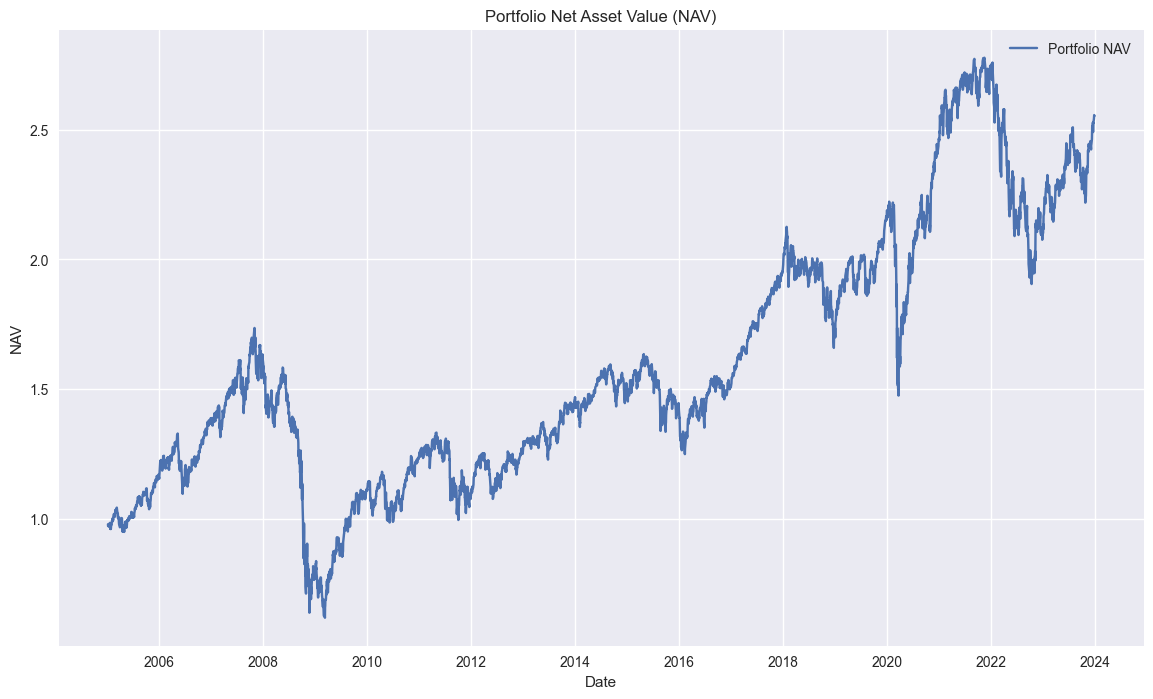

In [38]:
# -------------------------------------------------------
# Compute portfolio NAV
# -------------------------------------------------------
portfolio_nav = (1 + portfolio_returns).cumprod()
portfolio_nav.name = "Portfolio NAV"

# -------------------------------------------------------
# Plot NAV
# -------------------------------------------------------
plt.figure(figsize=(14, 8))
plt.plot(portfolio_nav, label="Portfolio NAV")
plt.title("Portfolio Net Asset Value (NAV)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)
plt.show()


## Drawdown Analysis

Drawdown measures cumulative losses from historical peaks and is a key indicator used by
risk managers to assess downside risk and capital erosion during stress periods.


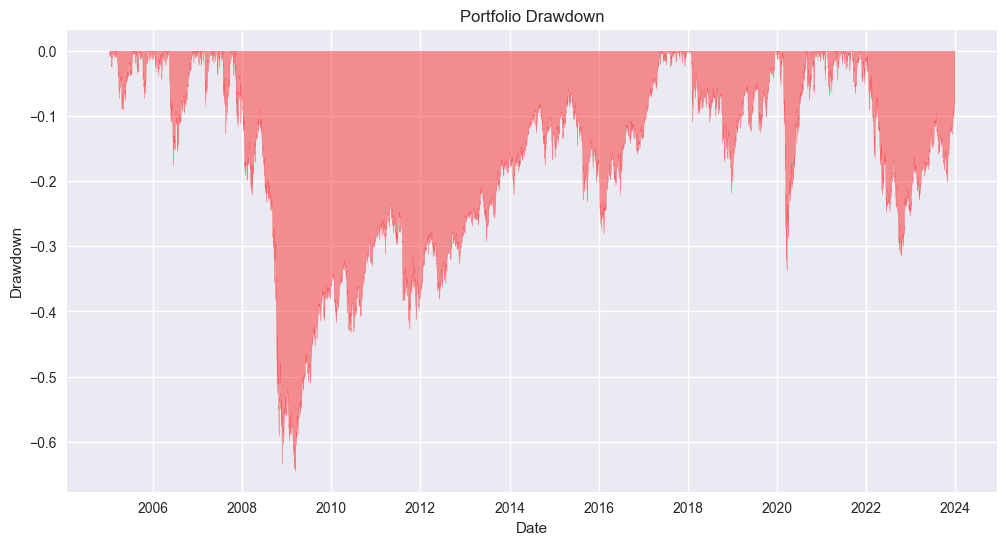

Maximum Drawdown: -64.42%


In [39]:
# -------------------------------------------------------
# Compute drawdowns
# -------------------------------------------------------
rolling_max = portfolio_nav.cummax()
drawdown = portfolio_nav / rolling_max - 1
drawdown.name = "Drawdown"

max_drawdown = drawdown.min()

# -------------------------------------------------------
# Plot drawdowns
# -------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.fill_between(drawdown.index, drawdown, color="red", alpha=0.4)
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

## Distribution of Portfolio Returns

The distribution of returns highlights tail risk and deviation from normality,
which justifies the use of stress testing beyond standard risk measures.

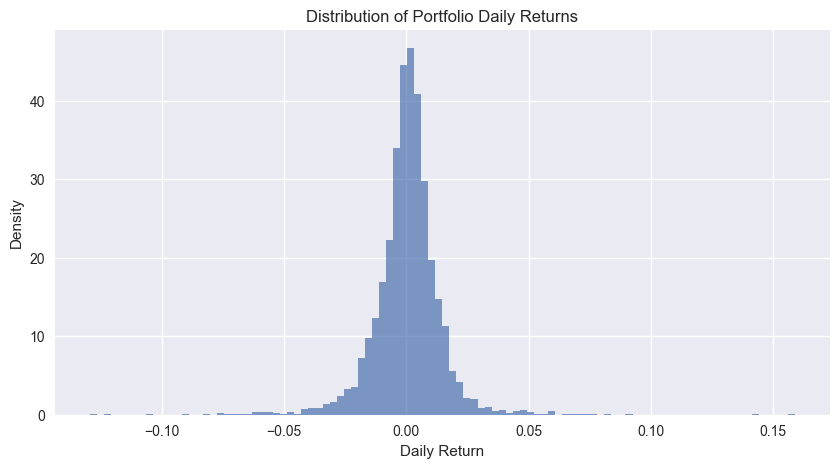

In [40]:
plt.figure(figsize=(10, 5))
plt.hist(portfolio_returns, bins=100, density=True, alpha=0.7)
plt.title("Distribution of Portfolio Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.grid(True)
plt.show()

## Baseline Risk Metrics Summary

The table below summarizes key baseline market risk indicators used as benchmarks
for stressed scenario comparisons.

In [41]:
# -------------------------------------------------------
# Risk metrics summary table
# -------------------------------------------------------
risk_metrics = pd.DataFrame(
    {
        "Metric": [
            "VaR 95%",
            "ES 95%",
            "VaR 99%",
            "ES 99%",
            "Maximum Drawdown"
        ],
        "Value": [
            var_95,
            es_95,
            var_99,
            es_99,
            max_drawdown
        ]
    }
)

# Format as percentages
risk_metrics["Value"] = risk_metrics["Value"].apply(lambda x: f"{x:.2%}")

risk_metrics

,Metric,Value
0,VaR 95%,-1.99%
1,ES 95%,-3.40%
2,VaR 99%,-4.02%
3,ES 99%,-6.12%
4,Maximum Drawdown,-64.42%


## 5. Stress Testing Framework

To ensure reusability and clarity, stress scenarios are implemented through a modular framework allowing:
- Historical scenario replay
- Hypothetical parameter shocks
- Comparison with baseline risk metrics


In [42]:
class StressTestEngine:
    def __init__(self, returns):
        self.returns = returns

    def historical_scenario(self, start, end):
        return self.returns.loc[start:end]

    def volatility_shock(self, multiplier):
        return self.returns * multiplier


In [43]:
# -------------------------------------------------------
# Instantiate stress testing engine
# -------------------------------------------------------
stress_engine = StressTestEngine(portfolio_returns)

# Quick sanity check
stress_engine.returns.describe()

count    4780.000000
mean        0.000294
std         0.013984
min        -0.129416
25%        -0.005428
50%         0.000842
75%         0.006775
max         0.158737
Name: Portfolio Returns, dtype: float64

## 6. Historical Stress Scenario – Global Financial Crisis (2008)

This scenario reproduces market dynamics observed during the 2008 financial crisis, characterized by:
- Extreme drawdowns
- Volatility spikes
- Strong cross-asset correlations


In [44]:
stress_engine = StressTestEngine(portfolio_returns)

returns_2008 = stress_engine.historical_scenario("2008-01-01", "2009-03-31")

cum_pnl_2008 = (1 + returns_2008).cumprod()


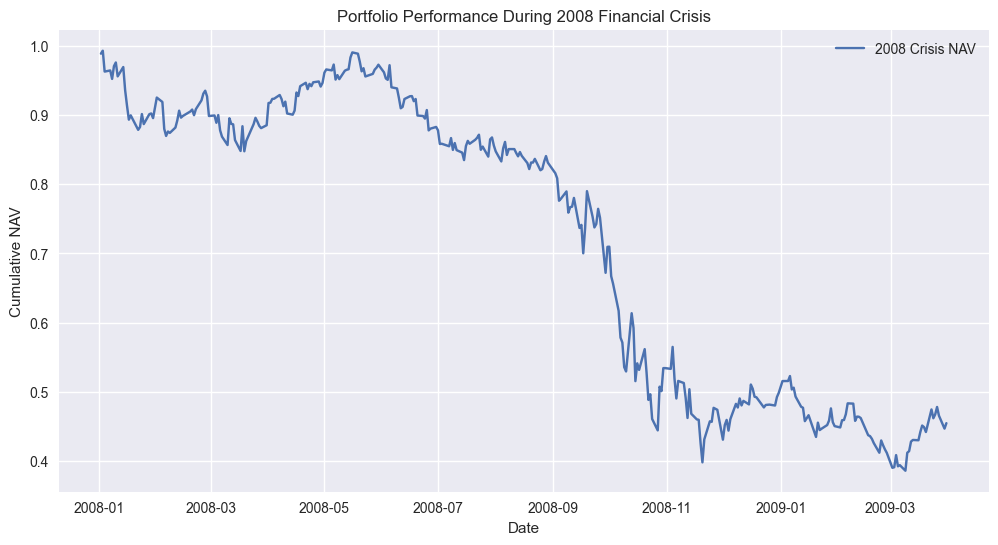

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(cum_pnl_2008, label="2008 Crisis NAV")
plt.title("Portfolio Performance During 2008 Financial Crisis")
plt.xlabel("Date")
plt.ylabel("Cumulative NAV")
plt.legend()
plt.grid(True)
plt.show()

## 7. Historical Stress Scenario – COVID-19 (2020)

The COVID-19 crisis differs from 2008 by:
- Speed of market collapse
- Short but intense volatility regime
- Rapid policy intervention


In [46]:
returns_covid = stress_engine.historical_scenario("2020-02-15", "2020-04-30")


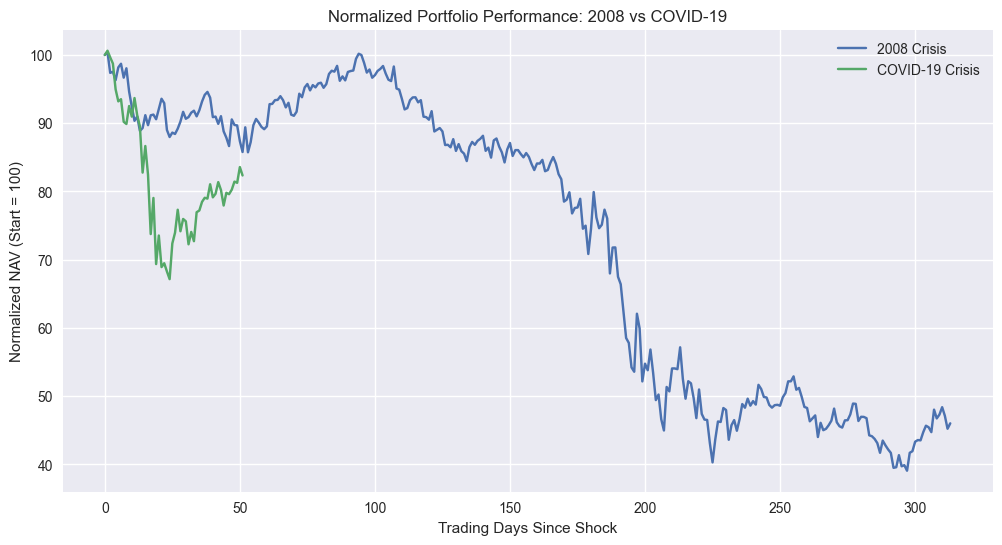

In [47]:
# -------------------------------------------------------
# Normalize cumulative PnL to 100
# -------------------------------------------------------
cum_2008_norm = 100 * cum_pnl_2008 / cum_pnl_2008.iloc[0]
cum_covid_norm = 100 * cum_pnl_covid / cum_pnl_covid.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(cum_2008_norm.values, label="2008 Crisis")
plt.plot(cum_covid_norm.values, label="COVID-19 Crisis")

plt.title("Normalized Portfolio Performance: 2008 vs COVID-19")
plt.xlabel("Trading Days Since Shock")
plt.ylabel("Normalized NAV (Start = 100)")
plt.legend()
plt.grid(True)
plt.show()

## 8. Hypothetical Stress Scenarios

In addition to historical events, hypothetical shocks are used to explore extreme but plausible conditions:
- Volatility shocks (×2, ×3)
- Correlation breakdown (conceptual discussion)


In [48]:
returns_vol_stress = stress_engine.volatility_shock(multiplier=2.5)


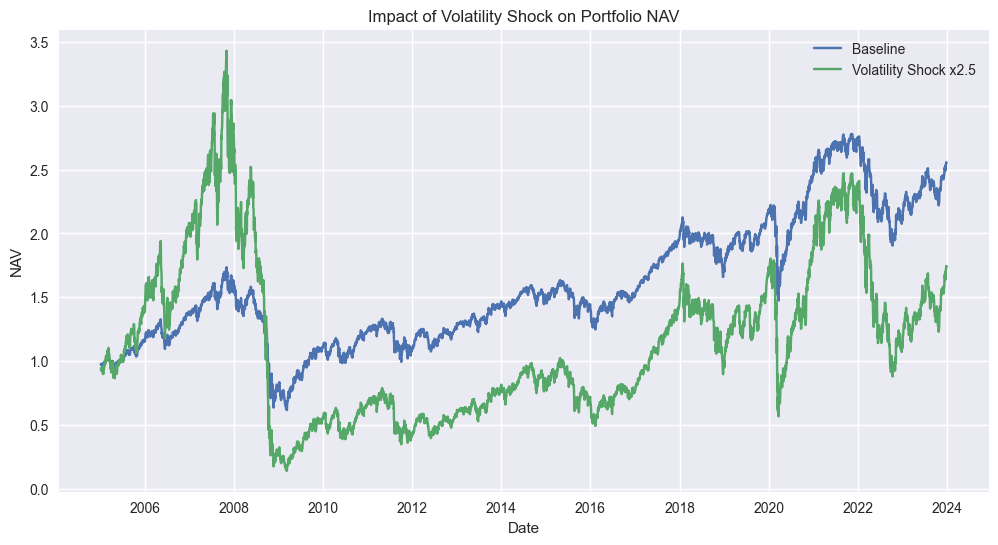

In [49]:
cum_pnl_vol_stress = (1 + returns_vol_stress).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(portfolio_nav, label="Baseline")
plt.plot(cum_pnl_vol_stress, label="Volatility Shock x2.5")
plt.title("Impact of Volatility Shock on Portfolio NAV")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)
plt.show()

## 9. Sensitivity Analysis to Market Risk Factors

We analyze portfolio sensitivity to:
- Volatility level
- Correlation regime

This helps identify the dominant drivers of portfolio risk.


## 10. Risk Interpretation and Management Insights

Key observations:
- Stressed losses significantly exceed baseline VaR and ES
- COVID-like scenarios produce faster drawdowns than 2008
- Portfolio vulnerability is strongly driven by volatility clustering

Such insights are directly exploitable for:
- Risk committees
- Internal risk appetite monitoring
- Regulatory stress exercises


## 11. Conclusion and Possible Extensions

This project demonstrates a practical implementation of a market risk stress testing engine aligned with banking practices.

Possible extensions include:
- Monte Carlo stress testing
- Liquidity-adjusted stress scenarios
- Credit spread and multi-asset extensions
- Machine learning-based regime detection
